# 07(사전) — 카드 무사용 552개 인사이트 EDA

**목적:** 36개월 내내 카드 0원인 552개 법인에서 실행 가능한 인사이트를 도출한다. 네 가지 질문에 수치로 답한다.
① 누가 안 쓰나(업종·권역 편중) ② 은행 관계가 커지는 중인가 식는 중인가(공략 우선순위) ③ 지출은 있는데 카드로 안 하는 것인가(전환 가능 결제 실증) ④ 무사용→사용 전환은 실제로 어떤 맥락에서 일어났나(후발 활성화 자연실험) + 잠재 카드 규모 추정.

**입력:** `data/raw/데이터.parquet` / **출력:** `outputs/figures/07_*.png`, `outputs/tables/07_*.csv`

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common
from common import IM, SERIES, SEED, set_korean_font, load_data, save_fig, ID, YM, CARD
np.random.seed(SEED)
set_korean_font()
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)

df = load_data()
months = sorted(df[YM].unique())
cnt = df.groupby(ID)[YM].nunique()
d1 = df[df[ID].isin(cnt[cnt == 36].index)].copy()
tot = d1.groupby(ID)[CARD].sum().sort_values(ascending=False)
dom = tot.index[0]
zero_ids = tot[tot == 0].index                      # 무사용 552
user_ids = tot.index.difference([dom]).difference(zero_ids)   # 사용군 2,819
assert len(zero_ids) == 552 and len(user_ids) == 2819

d1['총수신'] = d1[['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액']].sum(axis=1)
d1['총여신'] = d1['여신_운전자금대출잔액'] + d1['여신_시설자금대출잔액']
d1['디지털'] = d1['인터넷뱅킹거래금액'] + d1['스마트뱅킹거래금액']
d1['지출성'] = d1['요구불출금금액'] + d1['자동이체금액']
print(f'무사용 {len(zero_ids)}개 / 사용군 {len(user_ids):,}개')

무사용 552개 / 사용군 2,819개


## 1. 누가 안 쓰나 — 업종·권역 편중

,업종,무사용군 내 비중,사용군 내 비중,배율(무사용/사용),무사용 법인 수
3,부동산업,21.74,5.29,4.11,120
7,"협회 및 단체, 수리 및 기타 개인 서비스업",3.99,2.13,1.87,22
5,"사업시설 관리, 사업 지원 및 임대 서비스업",3.80,3.05,1.25,21
8,숙박 및 음식점업,1.99,1.74,1.15,11
6,"전문, 과학 및 기술 서비스업",2.72,2.41,1.13,15
4,운수 및 창고업,4.17,4.22,0.99,23
1,도매 및 소매업,17.75,21.57,0.82,98
9,"수도, 하수 및 폐기물 처리, 원료 재생업",1.27,1.67,0.76,7
0,제조업,25.54,33.77,0.76,141
2,건설업,10.33,18.66,0.55,57


권역 대구: 무사용군 41.1% vs 사용군 45.1% (배율 0.91)
권역 경북: 무사용군 28.6% vs 사용군 36.9% (배율 0.78)
권역 수도권: 무사용군 17.9% vs 사용군 5.3% (배율 3.42)
권역 부울경: 무사용군 5.3% vs 사용군 7.4% (배율 0.71)
권역 기타: 무사용군 2.9% vs 사용군 0.9% (배율 3.14)


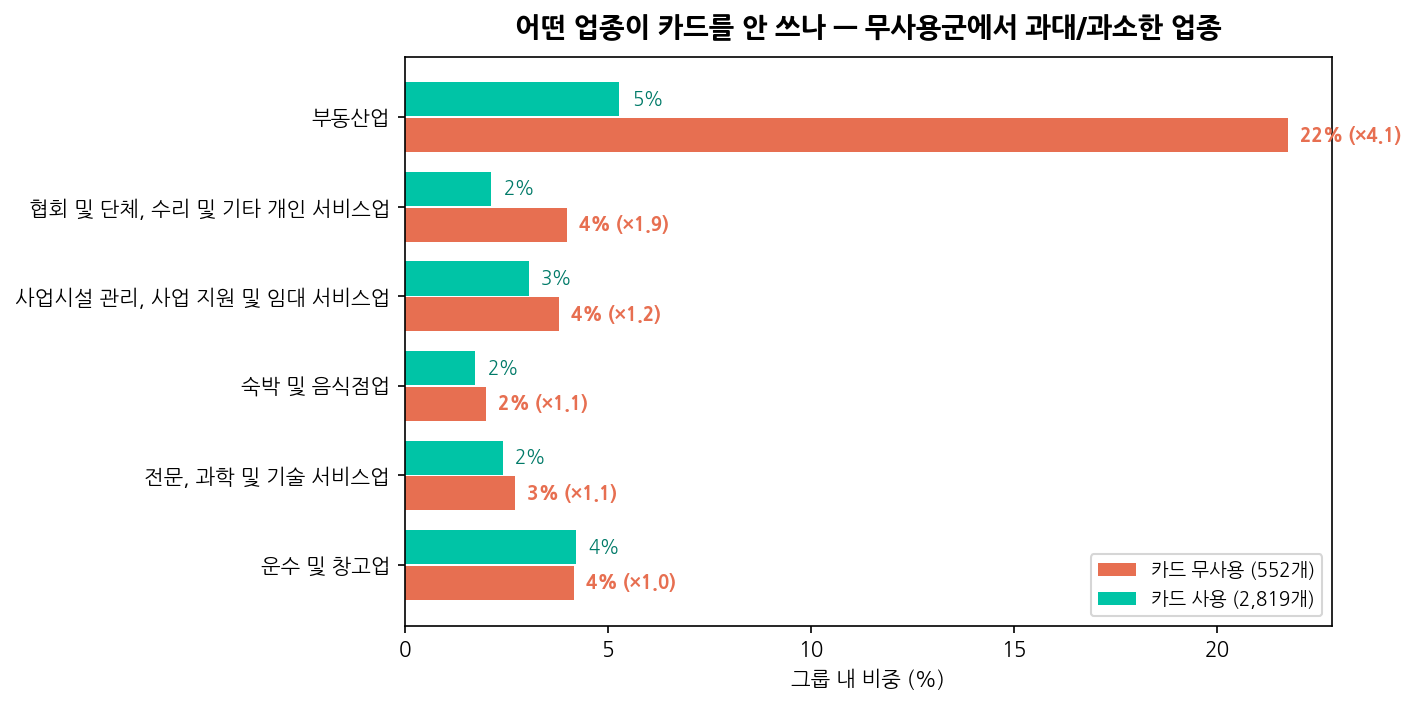

In [2]:
snap = d1[d1[YM] == 202512].set_index(ID)
zg, ug = snap.loc[snap.index.isin(zero_ids)], snap.loc[snap.index.isin(user_ids)]

rows = []
for ind in snap['업종_대분류'].value_counts().head(10).index:
    sz, su = (zg['업종_대분류'] == ind).mean(), (ug['업종_대분류'] == ind).mean()
    rows.append({'업종': ind, '무사용군 내 비중': sz * 100, '사용군 내 비중': su * 100,
                 '배율(무사용/사용)': sz / su if su > 0 else np.nan,
                 '무사용 법인 수': int((zg['업종_대분류'] == ind).sum())})
ind_tab = pd.DataFrame(rows).sort_values('배율(무사용/사용)', ascending=False)
display(ind_tab.round(2))
ind_tab.to_csv('../outputs/tables/07_무사용_업종편중.csv', index=False, encoding='utf-8-sig')

for reg in ['대구', '경북', '수도권', '부울경', '기타']:
    sz, su = (zg['사업장_시도'] == reg).mean(), (ug['사업장_시도'] == reg).mean()
    print(f'권역 {reg}: 무사용군 {sz:.1%} vs 사용군 {su:.1%} (배율 {sz/su:.2f})')

top6 = ind_tab.head(6)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
yy = np.arange(len(top6))
ax.barh(yy + 0.2, top6['무사용군 내 비중'], height=0.38, color=IM['코랄'], label='카드 무사용 (552개)')
ax.barh(yy - 0.2, top6['사용군 내 비중'], height=0.38, color=IM['민트'], label='카드 사용 (2,819개)')
for y, (_, r) in zip(yy, top6.iterrows()):
    ax.text(r['무사용군 내 비중'] + 0.3, y + 0.2, f"{r['무사용군 내 비중']:.0f}% (×{r['배율(무사용/사용)']:.1f})",
            va='center', fontsize=9, color=IM['코랄'], fontweight='bold')
    ax.text(r['사용군 내 비중'] + 0.3, y - 0.2, f"{r['사용군 내 비중']:.0f}%", va='center', fontsize=9, color=IM['딥민트'])
ax.set_yticks(yy); ax.set_yticklabels(top6['업종'], fontsize=10); ax.invert_yaxis()
ax.set_xlabel('그룹 내 비중 (%)')
ax.legend(fontsize=9, loc='lower right')
ax.set_title('어떤 업종이 카드를 안 쓰나 — 무사용군에서 과대/과소한 업종', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout(); save_fig(fig, '07_01_무사용_업종편중.png'); plt.show()

**해석 —** ① **부동산업이 무사용의 제1 업종이다**: 무사용군의 21.7%(120개)로 사용군 내 비중(5.3%)의 ×4.1이다. 임대·관리업은 지출 구조상 카드 결제(물품 구매·경비) 수요 자체가 적은 업종 — "안 쓰는" 게 아니라 "쓸 일이 적은" 구조적 미수요일 가능성이 크다. 반면 제조(×0.76)·건설(×0.55)은 무사용군에서 과소하다 — 이 업종인데 안 쓰는 법인(제조 141개, 건설 57개)은 구조가 아니라 습관·타사 이용 문제일 가능성이 높아 전환 여지가 크다. ② **권역 편중은 더 극적이다**: 수도권 ×3.42(17.9% vs 5.3%, 약 99개), 기타 권역 ×3.14 — 영업권 밖 법인은 대출만 받고 결제·카드는 타행에서 하는 '반쪽 거래' 패턴으로 추정된다. **시사점: 공략 메시지를 이원화해야 한다** — 구조적 미수요(부동산·비주거래권)와 습관적 미사용(제조·건설·고지출)은 다른 접근이 필요하다.

## 2. 관계가 커지는 중인가 — 초기(2023년) 대비 최근(2025년) 수신·여신 추이

총수신         총여신      
            무사용   사용군   무사용   사용군
확대(+20%↑)  34.2  38.7   7.2  15.6
신규 발생       1.8   0.7   0.2   1.4
유지         18.3  22.7  64.5  57.3
축소(-20%↓)  40.9  36.7  23.6  22.0
거래 없음       4.7   1.2   4.5   3.7

무사용 552개 중 여신 확대·신규 = 41개(7.4%) — 관계가 커지는 중인데 카드만 없는 법인


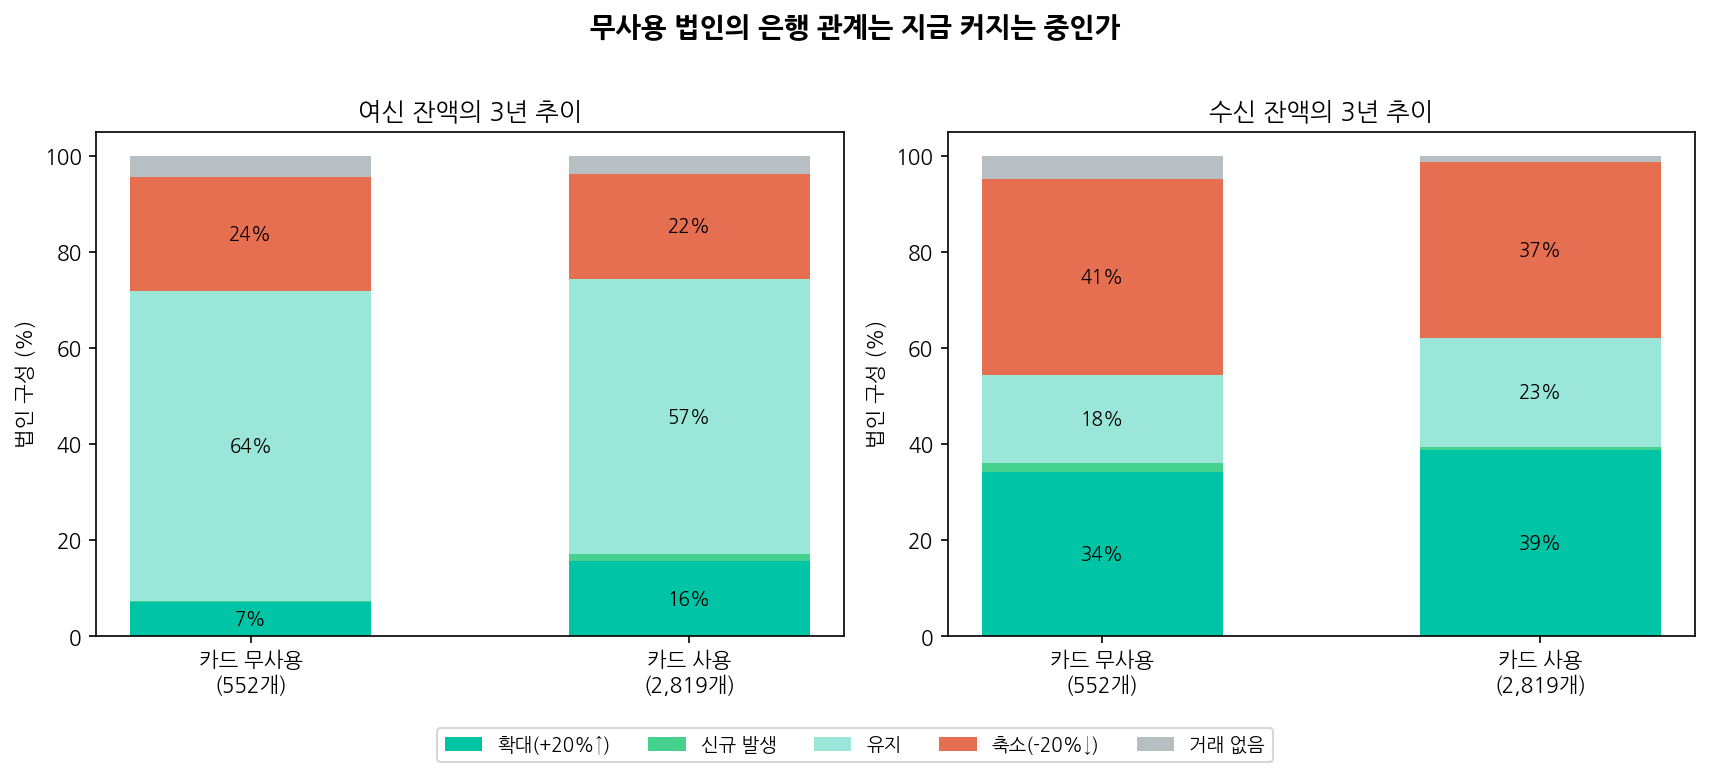

In [3]:
def growth_class(first, last, thr=0.2):
    if first == 0 and last == 0: return '거래 없음'
    if first == 0 and last > 0: return '신규 발생'
    r = last / first - 1
    return '확대(+20%↑)' if r > thr else ('축소(-20%↓)' if r < -thr else '유지')

early = d1[(d1[YM] >= 202302) & (d1[YM] <= 202312)].groupby(ID)[['총수신', '총여신']].mean()
late = d1[d1[YM] >= 202501].groupby(ID)[['총수신', '총여신']].mean()

res = {}
for col in ['총수신', '총여신']:
    for gname, ids in [('무사용', zero_ids), ('사용군', user_ids)]:
        cl = [growth_class(early.loc[i, col], late.loc[i, col]) for i in ids]
        res[(col, gname)] = pd.Series(cl).value_counts(normalize=True) * 100

order_cls = ['확대(+20%↑)', '신규 발생', '유지', '축소(-20%↓)', '거래 없음']
comp = pd.DataFrame(res).reindex(order_cls).fillna(0).round(1)
display(comp)
comp.to_csv('../outputs/tables/07_무사용_관계추이.csv', encoding='utf-8-sig')

z_loan = pd.Series([growth_class(early.loc[i, '총여신'], late.loc[i, '총여신']) for i in zero_ids], index=zero_ids)
n_exp = int((z_loan == '확대(+20%↑)').sum() + (z_loan == '신규 발생').sum())
print(f'무사용 552개 중 여신 확대·신규 = {n_exp}개({n_exp/552:.1%}) — 관계가 커지는 중인데 카드만 없는 법인')

colors = {'확대(+20%↑)': IM['민트'], '신규 발생': IM['그린'], '유지': IM['연민트'],
          '축소(-20%↓)': IM['코랄'], '거래 없음': IM['중립']}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
for ax, col in [(axes[0], '총여신'), (axes[1], '총수신')]:
    sub = comp[[(col, '무사용'), (col, '사용군')]]
    bottom = np.zeros(2)
    for cls in order_cls:
        v = sub.loc[cls].values
        ax.bar(['카드 무사용\n(552개)', '카드 사용\n(2,819개)'], v, bottom=bottom, color=colors[cls],
               label=cls if col == '총여신' else None, width=0.55)
        for i, vv in enumerate(v):
            if vv >= 7:
                ax.text(i, bottom[i] + vv/2, f'{vv:.0f}%', ha='center', va='center', fontsize=9)
        bottom += v
    ax.set_title(f'{col[1:]} 잔액의 3년 추이', fontsize=12)
    ax.set_ylabel('법인 구성 (%)')
fig.legend(loc='upper center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, 0.0))
fig.suptitle('무사용 법인의 은행 관계는 지금 커지는 중인가', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); save_fig(fig, '07_02_무사용_관계추이.png'); plt.show()

**해석 —** 무사용군의 은행 관계는 대체로 안정 유지형이다(여신 유지 64.5%). 수신은 확대 34.2% vs 축소 40.9%로 사용군(38.7%/36.7%)보다 약간 식는 쪽에 기울어 있다. 주목할 것은 **여신이 확대·신규인 41개(7.4%)** — 대출이 커지는 국면은 지출·투자가 커지는 국면이므로 "지금 접촉해야 할" 최우선 리스트다. 반대로 수신·여신이 모두 축소인 법인은 카드 제안 이전에 관계 회복이 선행되어야 한다.

## 3. 지출은 있는데 카드로 안 하는 것인가 — 결제성 거래(요구불 출금 + 자동이체) 실증

무사용 552개 결제성 거래 월평균: 중앙값 27.3백만원 (사용군 187.9)
  월 5백만원 이상 지출: 427개 (77.4%)
  월 10백만원 이상 지출: 368개 (66.7%)
  월 50백만원 이상 지출: 221개 (40.0%)
  월 100백만원 이상 지출: 152개 (27.5%)
사용군 벤치마크: 카드 월평균 / 결제성 월평균 중앙값 = 0.020


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


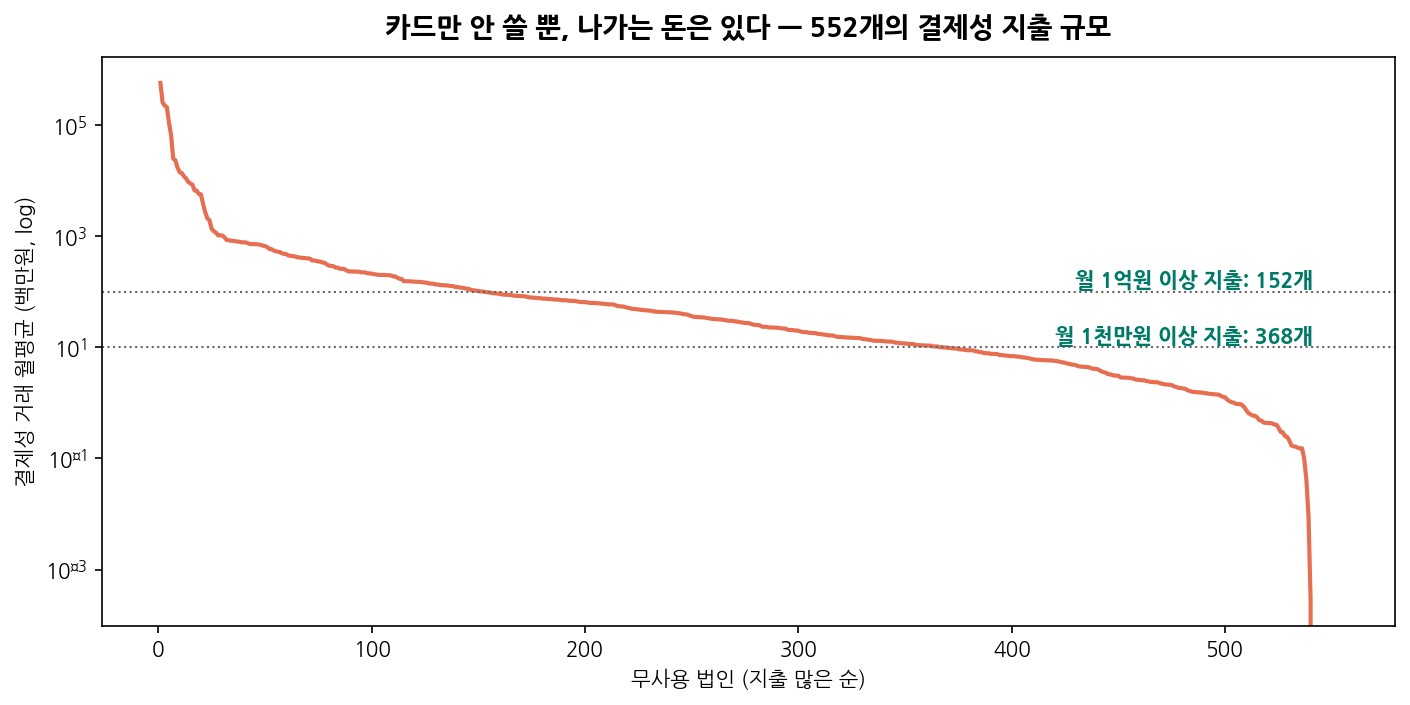

In [4]:
pay_z = d1[d1[ID].isin(zero_ids) & (d1[YM] >= 202302)].groupby(ID)['지출성'].mean().sort_values(ascending=False)
pay_u = d1[d1[ID].isin(user_ids) & (d1[YM] >= 202302)].groupby(ID)['지출성'].mean()

print(f'무사용 552개 결제성 거래 월평균: 중앙값 {pay_z.median():.1f}백만원 (사용군 {pay_u.median():.1f})')
for thr in [5, 10, 50, 100]:
    n = int((pay_z >= thr).sum())
    print(f'  월 {thr}백만원 이상 지출: {n}개 ({n/552:.1%})')

card_u = d1[d1[ID].isin(user_ids) & (d1[YM] >= 202302)].groupby(ID)[CARD].mean()
mask = pay_u > 0
ratio = (card_u[mask] / pay_u[mask]).median()
print(f'사용군 벤치마크: 카드 월평균 / 결제성 월평균 중앙값 = {ratio:.3f}')

fig, ax = plt.subplots(figsize=(9.5, 4.8))
xs = np.arange(1, len(pay_z) + 1)
ax.plot(xs, pay_z.values, color=IM['코랄'], lw=2)
ax.set_yscale('log')
for thr, txt in [(10, '월 1천만원'), (100, '월 1억원')]:
    n = int((pay_z >= thr).sum())
    ax.axhline(thr, color=IM['그레이'], ls=':', lw=1)
    ax.text(len(pay_z) * 0.98, thr * 1.2, f'{txt} 이상 지출: {n}개', ha='right', fontsize=10, color=IM['딥민트'], fontweight='bold')
ax.set_xlabel('무사용 법인 (지출 많은 순)')
ax.set_ylabel('결제성 거래 월평균 (백만원, log)')
ax.set_title('카드만 안 쓸 뿐, 나가는 돈은 있다 — 552개의 결제성 지출 규모', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout(); save_fig(fig, '07_03_무사용_지출규모.png'); plt.show()
pay_z.rename('결제성_월평균').to_csv('../outputs/tables/07_무사용_지출규모.csv', encoding='utf-8-sig')

**해석 —** 카드를 안 쓸 뿐, 돈은 나가고 있다. 552개의 결제성 거래(요구불 출금 + 자동이체)는 월 중앙값 27.3백만원이며, **월 1천만원 이상 지출이 368개(66.7%), 월 1억원 이상이 152개(27.5%)**다. 대다수는 '지출이 없는 법인'이 아니라 **'카드 밖에서 지출하는 법인'**이다. 참고로 사용군에서도 카드는 결제성 지출의 약 2.0%(중앙값)에 그친다 — 법인 결제에서 카드의 자연 침투율 자체가 낮으므로, 전환 목표도 '지출 전체'가 아니라 '지출의 수 %'로 현실적으로 설정해야 한다.

## 4. 잠재 카드 규모 추정 — 두 가지 벤치마크 (참고 추정치)

In [5]:
# (a) 프로필 매칭: 사용군을 업종×여신규모 4분위로 묶어 카드 월중앙값 벤치마크
prof = snap[['업종_대분류']].copy()
loan_avg = d1[d1[YM] >= 202302].groupby(ID)['총여신'].mean()
prof['여신4분위'] = pd.qcut(loan_avg.reindex(prof.index).fillna(0), 4, labels=False, duplicates='drop')
bench_src = prof.loc[prof.index.isin(user_ids)].join(card_u.rename('카드'))
bench = bench_src.groupby(['업종_대분류', '여신4분위'])['카드'].median()
glob_med = card_u.median()

zq = prof.loc[prof.index.isin(zero_ids)]
est_a = zq.apply(lambda r: bench.get((r['업종_대분류'], r['여신4분위']),
                                     bench_src[bench_src['업종_대분류'] == r['업종_대분류']]['카드'].median()
                                     if (bench_src['업종_대분류'] == r['업종_대분류']).any() else glob_med), axis=1)
est_a = est_a.fillna(glob_med)

# (b) 지출 비율: 사용군의 카드/결제성 비율 중앙값을 552의 결제성 지출에 적용
est_b = pay_z * ratio

print(f'(a) 프로필 매칭 추정: 월 {est_a.sum():,.0f}백만원 (법인당 중앙값 {est_a.median():.1f})')
print(f'(b) 지출 비율 추정:  월 {est_b.sum():,.0f}백만원 (법인당 중앙값 {est_b.median():.1f})')
lo, hi = sorted([est_a.sum(), est_b.sum()])
print(f'→ 잠재 카드 사용액 참고 범위: 월 {lo:,.0f} ~ {hi:,.0f}백만원 (연 {lo*12/100:,.0f}억 ~ {hi*12/100:,.0f}억원)')
print(f'   비교: 분석 대상 2,819개의 실제 월 총액 평균 {d1[d1[ID].isin(user_ids) & (d1[YM]>=202302)].groupby(YM)[CARD].sum().mean():,.0f}백만원')
top30 = est_a.sort_values(ascending=False).head(30)
print(f'잠재액 상위 30개 법인이 추정치의 {top30.sum()/est_a.sum():.0%} — 소수 집중 공략 가능')
pd.DataFrame({'프로필매칭_월추정': est_a, '지출비율_월추정': est_b}).to_csv(
    '../outputs/tables/07_무사용_잠재규모.csv', encoding='utf-8-sig')

(a) 프로필 매칭 추정: 월 2,316백만원 (법인당 중앙값 2.7)
(b) 지출 비율 추정:  월 32,780백만원 (법인당 중앙값 0.5)
→ 잠재 카드 사용액 참고 범위: 월 2,316 ~ 32,780백만원 (연 278억 ~ 3,934억원)
   비교: 분석 대상 2,819개의 실제 월 총액 평균 19,099백만원
잠재액 상위 30개 법인이 추정치의 36% — 소수 집중 공략 가능


**해석 —** 잠재 규모는 추정 방법에 따라 넓게 벌어진다. **보수적 추정(사용군의 업종×여신규모 유사군 매칭)은 월 2,316백만원 ≈ 연 278억원**으로, 현재 분석 대상 2,819개 월 총액(19,099백만원)의 약 12%에 해당하는 신규 시장이다. 지출 비율 기반 상한(월 32,780백만원)은 소수 초대형 지출 법인이 끌어올린 값이라 상한 참고로만 둔다. 중요한 실행 시사점은 **상위 30개 법인이 잠재액의 36%를 차지**한다는 것 — 552개 전수 캠페인이 아니라 상위 집중 공략이 효율적이다. (한계: 유사군 매칭은 조잡한 벤치마크이며 실제 전환율을 반영하지 않는 참고 추정치다)

## 5. 자연실험 — 뒤늦게 카드를 쓰기 시작한 법인들: 활성화 직전에 무엇이 변했나

후발 활성화 법인(2023.08 이후 첫 사용 = 최소 6개월 무사용 선행): 101개


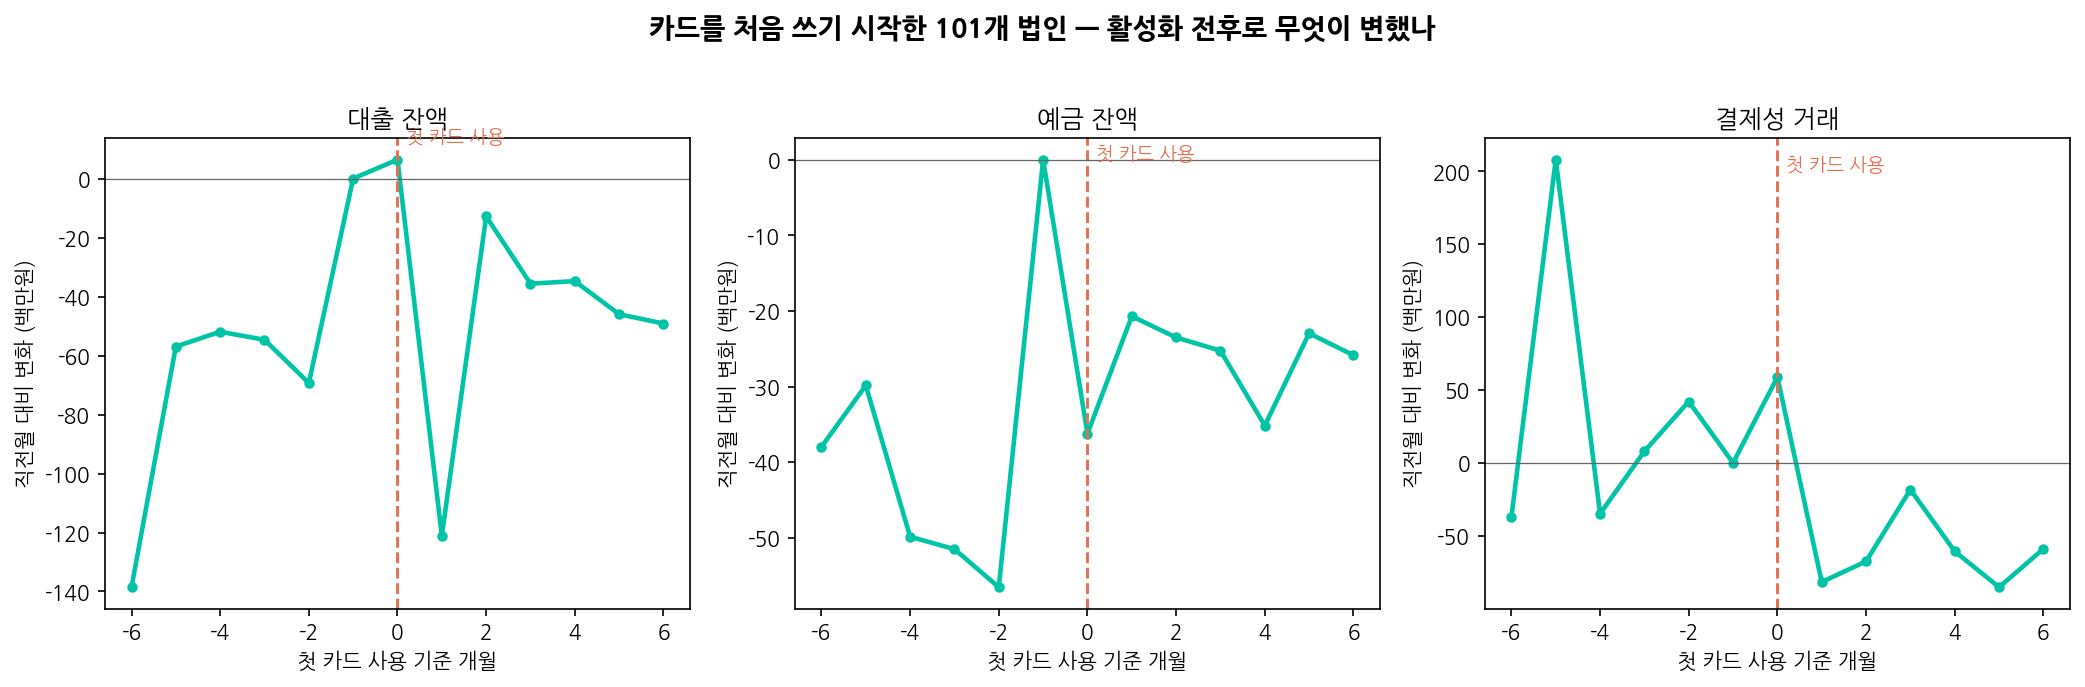

활성화 직전 6개월간 여신 증가 비율: 후발 활성화군 20.8% vs 무사용군 임의 시점 8.2%


In [6]:
card_mat = d1.pivot_table(index=ID, columns=YM, values=CARD).reindex(columns=months)
active = card_mat > 0
first_idx = np.where(active.values.any(axis=1), active.values.argmax(axis=1), -1)
first_s = pd.Series(first_idx, index=card_mat.index)

late_ids = first_s[(first_s >= months.index(202308)) & first_s.index.isin(user_ids)].index
print(f'후발 활성화 법인(2023.08 이후 첫 사용 = 최소 6개월 무사용 선행): {len(late_ids)}개')

mats = {m: d1.pivot_table(index=ID, columns=YM, values=m).reindex(columns=months) for m in ['총여신', '총수신', '지출성']}
offsets = list(range(-6, 7))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
traj = {}
for ax, m, ttl in [(axes[0], '총여신', '대출 잔액'), (axes[1], '총수신', '예금 잔액'), (axes[2], '지출성', '결제성 거래')]:
    ys = []
    for k in offsets:
        vals = []
        for cid in late_ids:
            t0 = first_s[cid]
            if 0 <= t0 + k < 36 and t0 - 1 >= 0:
                vals.append(mats[m].loc[cid].iloc[t0 + k] - mats[m].loc[cid].iloc[t0 - 1])
        ys.append(np.nanmean(vals))
    traj[m] = ys
    ax.plot(offsets, ys, marker='o', ms=4, lw=2.2, color=IM['민트'])
    ax.axvline(0, color=IM['코랄'], ls='--', lw=1.4)
    ax.axhline(0, color=IM['그레이'], lw=0.6)
    ax.text(0.2, ax.get_ylim()[1] * 0.9 if max(ys) > 0 else max(ys), '첫 카드 사용', fontsize=9, color=IM['코랄'])
    ax.set_xlabel('첫 카드 사용 기준 개월'); ax.set_ylabel('직전월 대비 변화 (백만원)')
    ax.set_title(ttl, fontsize=12)
fig.suptitle(f'카드를 처음 쓰기 시작한 {len(late_ids)}개 법인 — 활성화 전후로 무엇이 변했나',
             y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout(); save_fig(fig, '07_04_활성화_자연실험.png'); plt.show()

# 활성화 직전 6개월 여신 증가 비율 비교
pre_up = []
for cid in late_ids:
    t0 = first_s[cid]
    if t0 - 7 >= 0:
        pre_up.append(mats['총여신'].loc[cid].iloc[t0 - 1] > mats['총여신'].loc[cid].iloc[t0 - 7])
pre_rate = np.mean(pre_up)
base_up = []
rng = np.random.RandomState(SEED)
for cid in rng.choice(zero_ids, 400, replace=False):
    t0 = rng.randint(8, 35)
    base_up.append(mats['총여신'].loc[cid].iloc[t0 - 1] > mats['총여신'].loc[cid].iloc[t0 - 7])
print(f'활성화 직전 6개월간 여신 증가 비율: 후발 활성화군 {pre_rate:.1%} vs 무사용군 임의 시점 {np.mean(base_up):.1%}')

**해석 —** 무사용→사용 전환은 실제로 일어난다: 6개월 이상 무사용 후 카드를 쓰기 시작한 법인이 **101개**다. 핵심 발견은 **활성화 직전 6개월간 대출이 늘어난 비율이 20.8%로, 무사용군 임의 시점(8.2%)의 2.5배**라는 것 — 그림에서도 대출 잔액과 결제성 거래가 첫 카드 사용 시점을 전후해 함께 증가한다. 즉 **대출 이벤트(신규·증액)가 카드 활성화에 선행하는 경향**이 있으며, 이는 "여신 확대 중인 41개 최우선"(§2) 전략을 데이터로 뒷받침한다. **실행 규칙 제안: 무사용 법인에서 대출 신규·증액 이벤트가 발생하면 4주 내 카드 제안을 트리거로 설정한다.**

## 종합 — 07 비즈니스 인사이트로 가져갈 5가지

1. **공략 메시지 이원화** — 구조적 미수요(부동산 120개·비주거래권 수도권 약 99개: 카드 쓸 일이 적거나 주거래가 타행)와 습관적 미사용(제조 141·건설 57 + 고지출군: 지출은 있는데 카드 밖에서)은 다른 접근이 필요하다.
2. **우선순위 리스트 3종** — ① 여신 확대·신규 중 41개(지금 커지는 관계) ② 월 1억원 이상 지출 152개(전환할 결제가 실재) ③ 잠재액 상위 30개(잠재 규모의 36%). 세 리스트의 교집합이 최상위 타겟이다.
3. **행동 트리거** — 대출 신규·증액 이벤트 발생 시 4주 내 카드 제안(활성화 자연실험: 직전 대출 증가 비율이 평시의 2.5배).
4. **기대효과(보수)** — 유사군 수준으로 전환 시 연 약 278억원 잠재 카드 취급액(현 시장의 12%). 전환율 가정별 시나리오는 07 본편에서 수치화.
5. **휴면카드 98개부터** — 이미 발급된 카드는 활성화 캠페인만 필요해 가장 낮은 문턱의 전환이다. 위 우선순위 리스트와 교차하면 최우선 접촉 대상이 된다.

산출물: 그림 4장(07_01~07_04), 표 4개(업종편중·관계추이·지출규모·잠재규모).